## Fase 1.4, 1.5 y 1.6 — Serie mensual total de Chaco

**1.4 — Agrupar:** agrupar por `fecha` y sumar `FOB_dólar` y `Peso neto`,
obteniendo una serie mensual única de Chaco — sin distinguir por Rubro
todavía (eso queda para la Fase 4).

**1.5 — Graficar en USD:** línea de tiempo de la serie completa
2002-2026, en USD FOB.

**1.6 — Graficar en toneladas:** la misma serie, esta vez en `Peso neto`
(toneladas), al lado o debajo del gráfico anterior.

**Fuente:** `data/processed/chaco_serie_mensual_2002_2026.csv`
(ya con la columna `fecha` persistida en la Fase 1.3).

---

In [1]:
import os
os.chdir('..')

In [2]:
import pandas as pd

df = pd.read_csv('data/processed/chaco_serie_mensual_2002_2026.csv', parse_dates=['fecha'])

serie_mensual = (
    df.groupby('fecha')[['FOB_dólar', 'Peso neto']]
    .sum()
    .sort_index()
)

print(f"Filas: {len(serie_mensual)} (esperado: un valor por mes, 2002-01 a 2026-06)")
serie_mensual.head()

Filas: 294 (esperado: un valor por mes, 2002-01 a 2026-06)


,FOB_dólar,Peso neto
fecha,,
2002-01-01,9399279.66,3.694585e+07
2002-02-01,7097484.15,2.921114e+07
2002-03-01,12679160.26,7.748228e+07
2002-04-01,16550450.58,9.804934e+07
2002-05-01,17952473.03,1.079029e+08


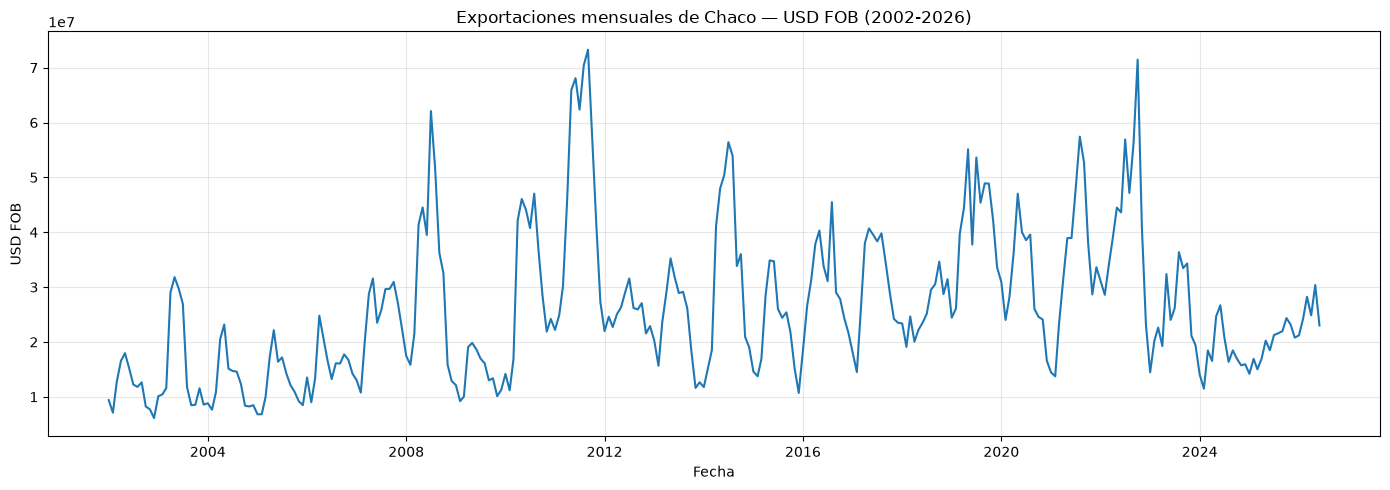

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_mensual.index, serie_mensual['FOB_dólar'])
ax.set_title('Exportaciones mensuales de Chaco — USD FOB (2002-2026)')
ax.set_xlabel('Fecha')
ax.set_ylabel('USD FOB')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

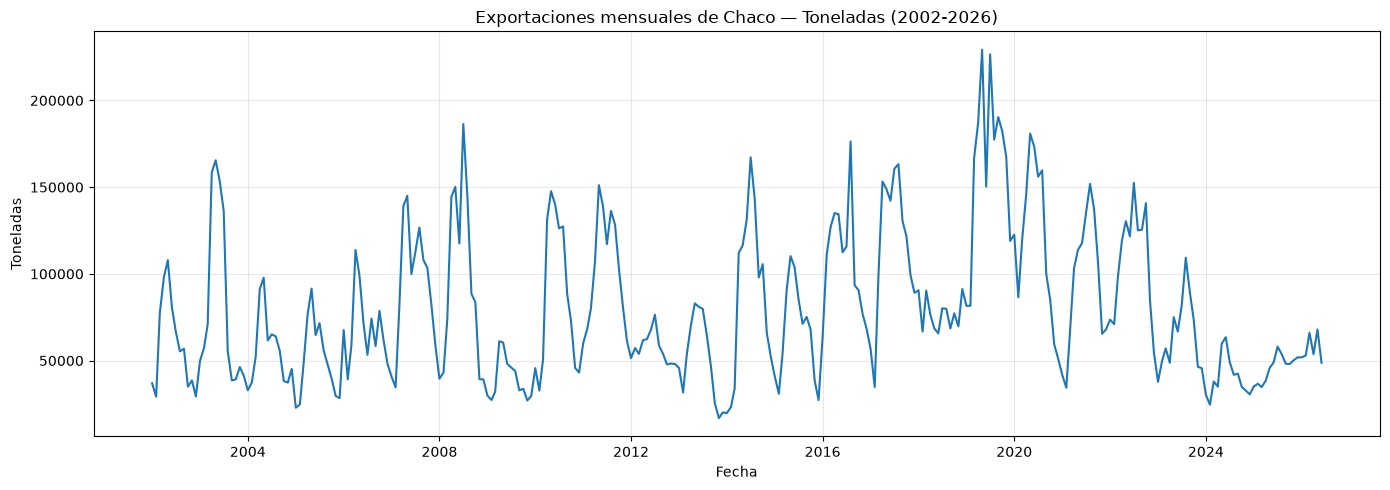

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_mensual.index, serie_mensual['Peso neto'] / 1000)
ax.set_title('Exportaciones mensuales de Chaco — Toneladas (2002-2026)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Toneladas')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Fase 1.7 — Marcar años clave en los gráficos

**Objetivo:** resaltar visualmente 2022 (pico previo), 2024 (piso) y 2026
(recuperación) sobre las series de USD y toneladas ya graficadas, para que
la narrativa del proyecto se vea de un vistazo.

---

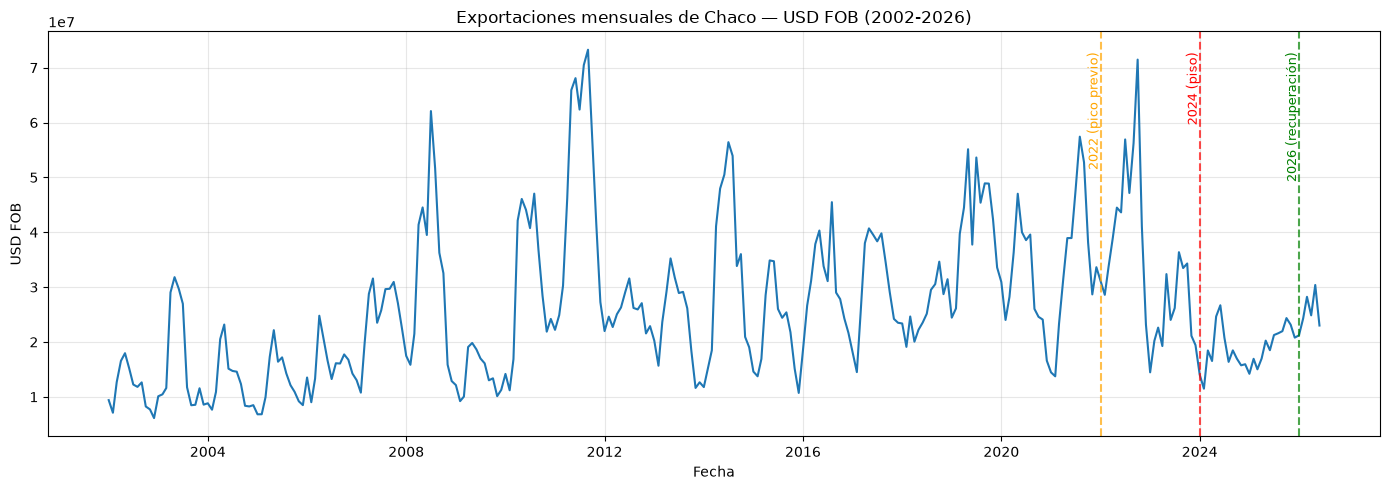

In [5]:
años_clave = {
    2022: ('2022 (pico previo)', 'orange'),
    2024: ('2024 (piso)', 'red'),
    2026: ('2026 (recuperación)', 'green'),
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_mensual.index, serie_mensual['FOB_dólar'])

for año, (etiqueta, color) in años_clave.items():
    fecha = pd.Timestamp(f'{año}-01-01')
    ax.axvline(fecha, color=color, linestyle='--', alpha=0.7)
    ax.text(fecha, ax.get_ylim()[1]*0.95, etiqueta, rotation=90,
            va='top', ha='right', color=color, fontsize=9)

ax.set_title('Exportaciones mensuales de Chaco — USD FOB (2002-2026)')
ax.set_xlabel('Fecha')
ax.set_ylabel('USD FOB')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

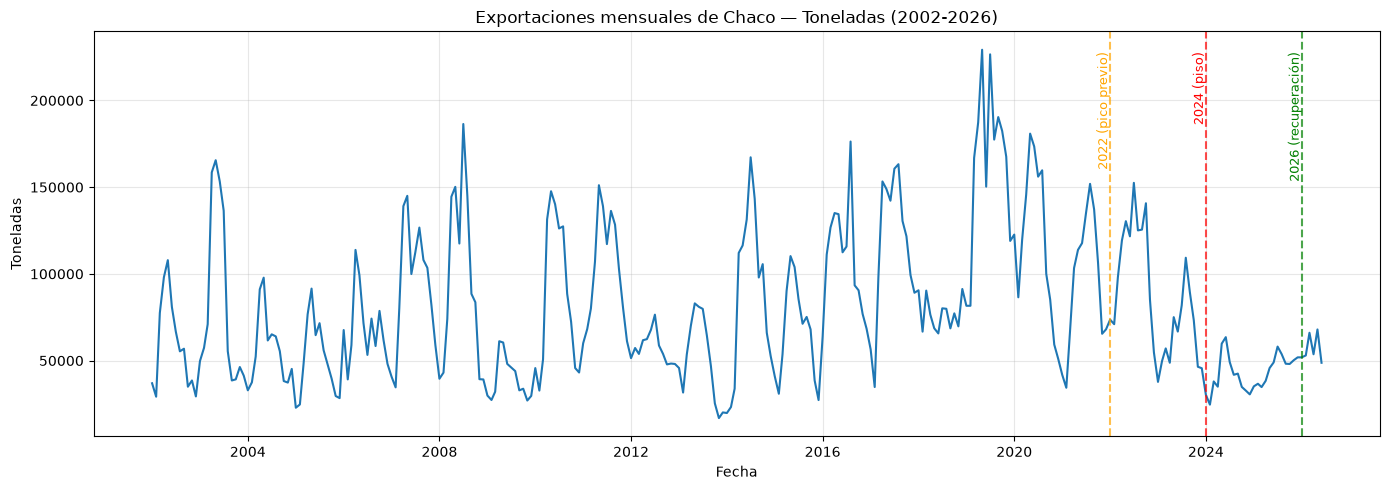

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_mensual.index, serie_mensual['Peso neto'] / 1000)

for año, (etiqueta, color) in años_clave.items():
    fecha = pd.Timestamp(f'{año}-01-01')
    ax.axvline(fecha, color=color, linestyle='--', alpha=0.7)
    ax.text(fecha, ax.get_ylim()[1]*0.95, etiqueta, rotation=90,
            va='top', ha='right', color=color, fontsize=9)

ax.set_title('Exportaciones mensuales de Chaco — Toneladas (2002-2026)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Toneladas')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()